# E-commerce Sales Analysis & Customer Segmentation
### Data Analytics Portfolio Project

**Objective:** Analyze e-commerce sales data to derive actionable business insights

**Key Analysis Areas:**
1. Sales Performance Analysis
2. Customer Segmentation (RFM Analysis)
3. Product Performance Analysis
4. Regional & Temporal Trends
5. Business Recommendations

## 1. Import Libraries & Setup

In [85]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date handling
from datetime import datetime, timedelta

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print(" Libraries imported successfully!")

 Libraries imported successfully!


## 2. Generate Synthetic E-commerce Dataset

In [86]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate dates (2 years of data)
start_date = datetime(2022, 1, 1)
end_date = datetime(2023, 12, 31)
date_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Number of transactions
n_transactions = 10000

# Generate transaction data
data = {
    'order_id': [f'ORD{str(i).zfill(6)}' for i in range(1, n_transactions + 1)],
    'order_date': np.random.choice(date_range, n_transactions),
    'customer_id': [f'CUST{str(i).zfill(5)}' for i in np.random.randint(1, 2001, n_transactions)],
    'product_category': np.random.choice(
        ['Electronics', 'Clothing', 'Home & Kitchen', 'Books', 'Sports', 'Beauty', 'Toys'],
        n_transactions,
        p=[0.25, 0.20, 0.15, 0.12, 0.10, 0.10, 0.08]
    ),
    'product_name': np.random.choice(
        ['Laptop', 'Smartphone', 'Headphones', 'T-Shirt', 'Jeans', 'Dress',
         'Coffee Maker', 'Blender', 'Novel', 'Cookbook', 'Yoga Mat', 'Dumbbell',
         'Face Cream', 'Perfume', 'Action Figure', 'Board Game'],
        n_transactions
    ),
    'quantity': np.random.randint(1, 6, n_transactions),
    'unit_price': np.random.uniform(10, 500, n_transactions).round(2),
    'region': np.random.choice(['North', 'South', 'East', 'West'], n_transactions),
    'payment_method': np.random.choice(['Credit Card', 'Debit Card', 'PayPal', 'Cash'], n_transactions)
}

# Create DataFrame
df = pd.DataFrame(data)

# Calculate total amount
df['total_amount'] = (df['quantity'] * df['unit_price']).round(2)

# Sort by date
df = df.sort_values('order_date').reset_index(drop=True)

print(f" Dataset created: {len(df)} transactions")
print(f" Date range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")
print(f" Unique customers: {df['customer_id'].nunique()}")
df.head(10)

 Dataset created: 10000 transactions
 Date range: 2022-01-01 to 2023-12-31
 Unique customers: 1989


,order_id,order_date,customer_id,product_category,product_name,quantity,unit_price,region,payment_method,total_amount
0,ORD009682,2022-01-01,CUST00630,Home & Kitchen,Novel,5,271.63,East,Cash,1358.15
1,ORD003552,2022-01-01,CUST00745,Electronics,Laptop,5,459.02,South,Debit Card,2295.10
2,ORD005170,2022-01-01,CUST01668,Toys,Cookbook,1,61.21,East,Credit Card,61.21
3,ORD006614,2022-01-01,CUST01374,Clothing,Board Game,5,327.71,West,Debit Card,1638.55
4,ORD008112,2022-01-01,CUST00446,Home & Kitchen,Laptop,2,360.94,West,PayPal,721.88
5,ORD000649,2022-01-01,CUST01012,Electronics,Perfume,2,185.51,East,Cash,371.02
6,ORD003247,2022-01-01,CUST01238,Sports,Yoga Mat,5,397.90,North,PayPal,1989.50
7,ORD006185,2022-01-01,CUST01386,Books,Face Cream,3,158.12,North,Debit Card,474.36
8,ORD001976,2022-01-01,CUST01862,Clothing,Yoga Mat,1,181.02,East,Credit Card,181.02
9,ORD006363,2022-01-01,CUST01060,Clothing,Dress,3,80.21,South,PayPal,240.63


## 3. Data Exploration & Quality Check

In [87]:
# Dataset info
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
df.describe()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          10000 non-null  object        
 1   order_date        10000 non-null  datetime64[ns]
 2   customer_id       10000 non-null  object        
 3   product_category  10000 non-null  object        
 4   product_name      10000 non-null  object        
 5   quantity          10000 non-null  int32         
 6   unit_price        10000 non-null  float64       
 7   region            10000 non-null  object        
 8   payment_method    10000 non-null  object        
 9   total_amount      10000 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int32(1), object(6)
memory usage: 742.3+ KB

STATISTICAL SUMMARY


,order_date,quantity,unit_price,total_amount
count,10000,10000.000000,10000.000000,10000.000000
mean,2023-01-01 14:10:45.120000,2.996900,254.003649,761.489978
min,2022-01-01 00:00:00,1.000000,10.010000,10.050000
25%,2022-07-02 00:00:00,2.000000,130.942500,288.370000
50%,2023-01-02 00:00:00,3.000000,252.230000,599.205000
75%,2023-07-05 00:00:00,4.000000,378.272500,1137.412500
max,2023-12-31 00:00:00,5.000000,499.990000,2499.950000
std,NaN,1.403812,141.975637,588.282174


In [88]:
# Check for missing values
print("=" * 60)
print("MISSING VALUES CHECK")
print("=" * 60)
missing = df.isnull().sum()
if missing.sum() == 0:
    print(" No missing values found!")
else:
    print(missing[missing > 0])

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\n Duplicate rows: {duplicates}")

MISSING VALUES CHECK
 No missing values found!

 Duplicate rows: 0


## 4. Sales Performance Analysis

In [89]:
# Key metrics
total_revenue = df['total_amount'].sum()
total_orders = len(df)
avg_order_value = df['total_amount'].mean()
unique_customers = df['customer_id'].nunique()

print("=" * 60)
print("KEY BUSINESS METRICS")
print("=" * 60)
print(f" Total Revenue: ${total_revenue:,.2f}")
print(f" Total Orders: {total_orders:,}")
print(f" Average Order Value: ${avg_order_value:,.2f}")
print(f" Unique Customers: {unique_customers:,}")
print(f" Avg Orders per Customer: {total_orders/unique_customers:.2f}")

KEY BUSINESS METRICS
 Total Revenue: $7,614,899.78
 Total Orders: 10,000
 Average Order Value: $761.49
 Unique Customers: 1,989
 Avg Orders per Customer: 5.03


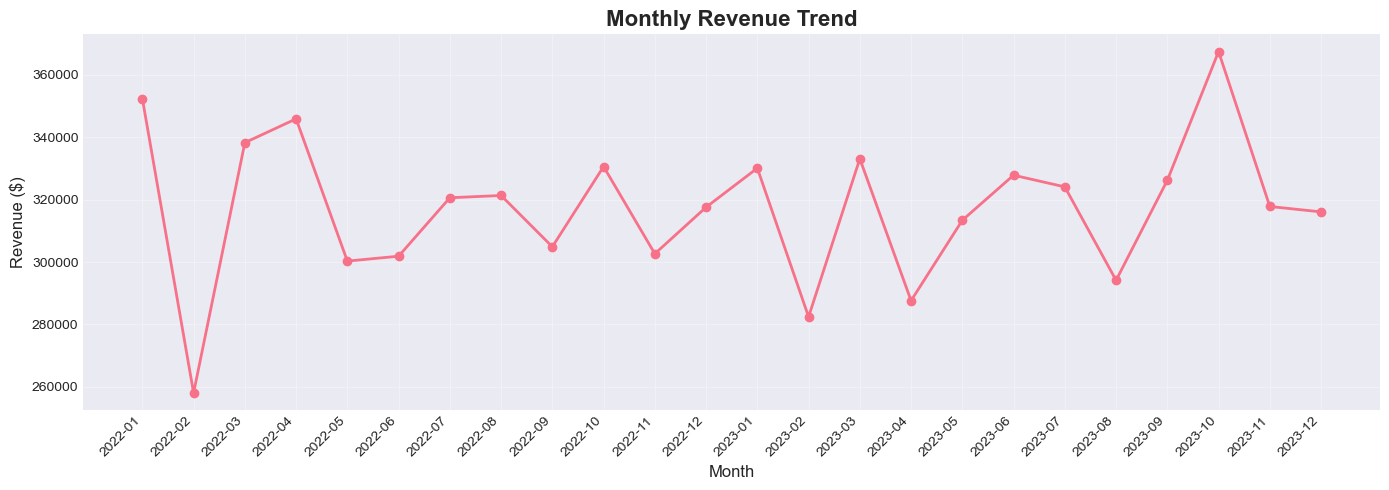

 Peak month: 2023-10
 Lowest month: 2022-02


In [90]:
# Monthly revenue trend
df['year_month'] = df['order_date'].dt.to_period('M')
monthly_revenue = df.groupby('year_month')['total_amount'].sum().reset_index()
monthly_revenue['year_month'] = monthly_revenue['year_month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue['year_month'], monthly_revenue['total_amount'], marker='o', linewidth=2, markersize=6)
plt.title('Monthly Revenue Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f" Peak month: {monthly_revenue.loc[monthly_revenue['total_amount'].idxmax(), 'year_month']}")
print(f" Lowest month: {monthly_revenue.loc[monthly_revenue['total_amount'].idxmin(), 'year_month']}")

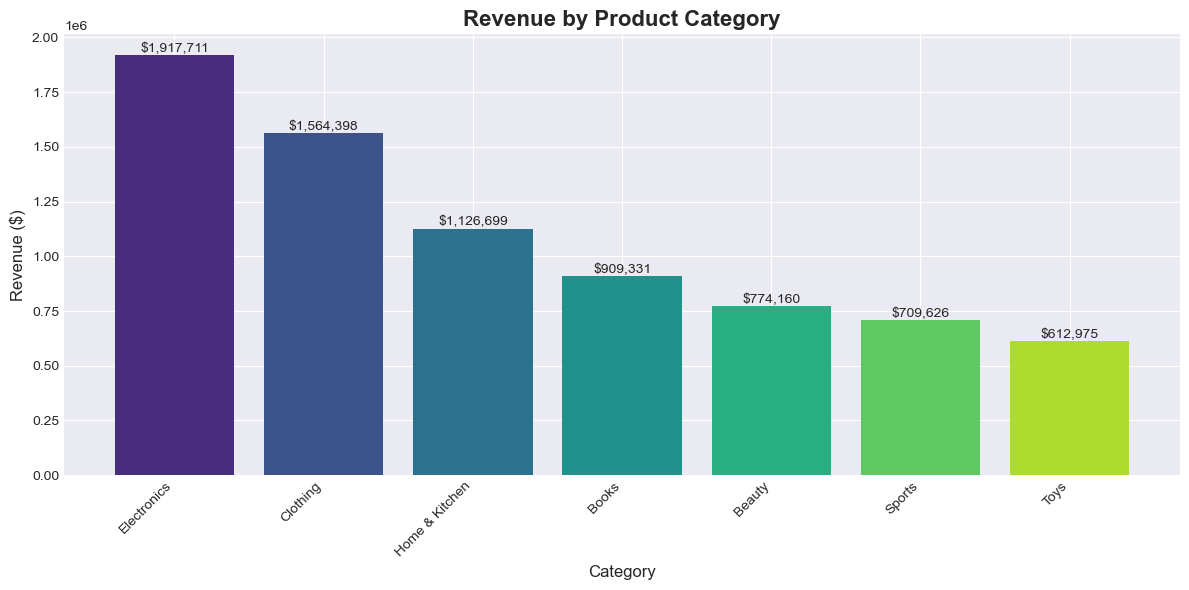


Top 3 Categories by Revenue:
1. Electronics: $1,917,710.81
2. Clothing: $1,564,397.88
3. Home & Kitchen: $1,126,699.39


In [91]:
# Revenue by category
category_revenue = df.groupby('product_category')['total_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(category_revenue.index, category_revenue.values, color=sns.color_palette('viridis', len(category_revenue)))
plt.title('Revenue by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:,.0f}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\nTop 3 Categories by Revenue:")
for i, (cat, rev) in enumerate(category_revenue.head(3).items(), 1):
    print(f"{i}. {cat}: ${rev:,.2f}")

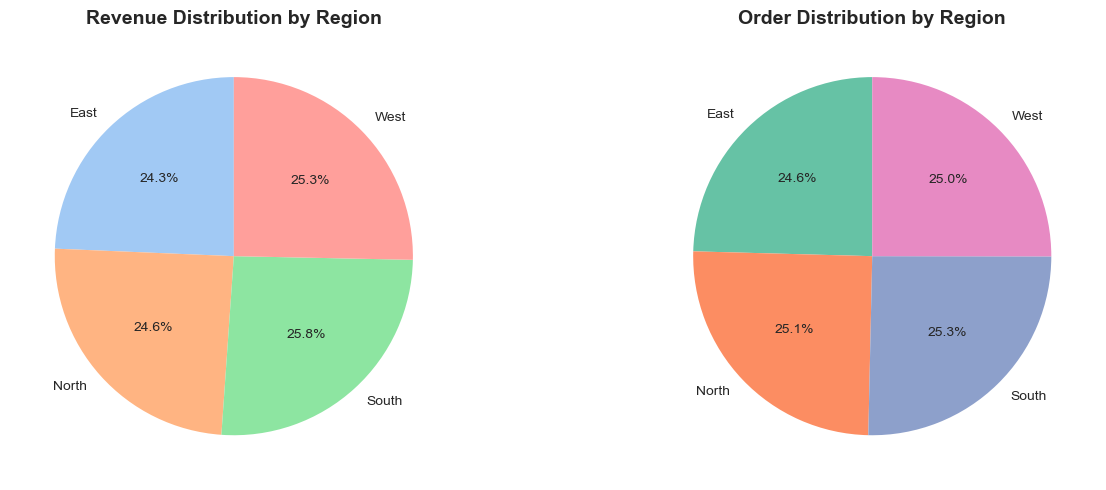


Regional Performance:
        total_amount  orders
region                      
South     1963182.47    2533
West      1928489.80    2502
North     1870436.52    2508
East      1852790.99    2457


In [92]:
# Regional performance
regional_data = df.groupby('region').agg({
    'total_amount': 'sum',
    'order_id': 'count'
}).rename(columns={'order_id': 'orders'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue by region
axes[0].pie(regional_data['total_amount'], labels=regional_data.index, autopct='%1.1f%%',
            startangle=90, colors=sns.color_palette('pastel'))
axes[0].set_title('Revenue Distribution by Region', fontsize=14, fontweight='bold')

# Orders by region
axes[1].pie(regional_data['orders'], labels=regional_data.index, autopct='%1.1f%%',
            startangle=90, colors=sns.color_palette('Set2'))
axes[1].set_title('Order Distribution by Region', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nRegional Performance:")
print(regional_data.sort_values('total_amount', ascending=False))

## 5. Customer Segmentation - RFM Analysis

In [93]:
# RFM Analysis (Recency, Frequency, Monetary)
# Reference date: one day after the last transaction
reference_date = df['order_date'].max() + timedelta(days=1)

rfm = df.groupby('customer_id').agg({
    'order_date': lambda x: (reference_date - x.max()).days,  # Recency
    'order_id': 'count',  # Frequency
    'total_amount': 'sum'  # Monetary
}).rename(columns={
    'order_date': 'Recency',
    'order_id': 'Frequency',
    'total_amount': 'Monetary'
})

print("=" * 60)
print("RFM ANALYSIS SUMMARY")
print("=" * 60)
print(rfm.describe())

rfm.head(10)

RFM ANALYSIS SUMMARY
           Recency    Frequency      Monetary
count  1989.000000  1989.000000   1989.000000
mean    140.614882     5.027652   3828.506677
std     138.297290     2.180658   2151.680248
min       1.000000     1.000000     25.420000
25%      41.000000     3.000000   2220.520000
50%      99.000000     5.000000   3558.970000
75%     190.000000     6.000000   5169.970000
max     728.000000    15.000000  12615.130000


,Recency,Frequency,Monetary
customer_id,,,
CUST00001,120,5,3176.80
CUST00002,213,2,875.46
CUST00003,307,4,3461.72
CUST00004,118,3,4199.24
CUST00005,63,3,2474.98
CUST00006,117,4,2796.95
CUST00007,273,4,2529.35
CUST00008,43,7,4049.11
CUST00009,27,6,5532.30


In [94]:
# Create RFM scores (1-5 scale)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])  # Lower recency = better
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# Calculate RFM score
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Total'] = rfm[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)

# Customer segmentation
def segment_customer(row):
    if row['RFM_Total'] >= 13:
        return 'VIP Champions'
    elif row['RFM_Total'] >= 10:
        return 'Loyal Customers'
    elif row['RFM_Total'] >= 7:
        return 'Potential Loyalists'
    elif row['RFM_Total'] >= 5:
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print("\nCustomer Segments:")
print(rfm['Segment'].value_counts())


Customer Segments:
Segment
Loyal Customers        557
Potential Loyalists    539
VIP Champions          363
At Risk                289
Lost Customers         241
Name: count, dtype: int64


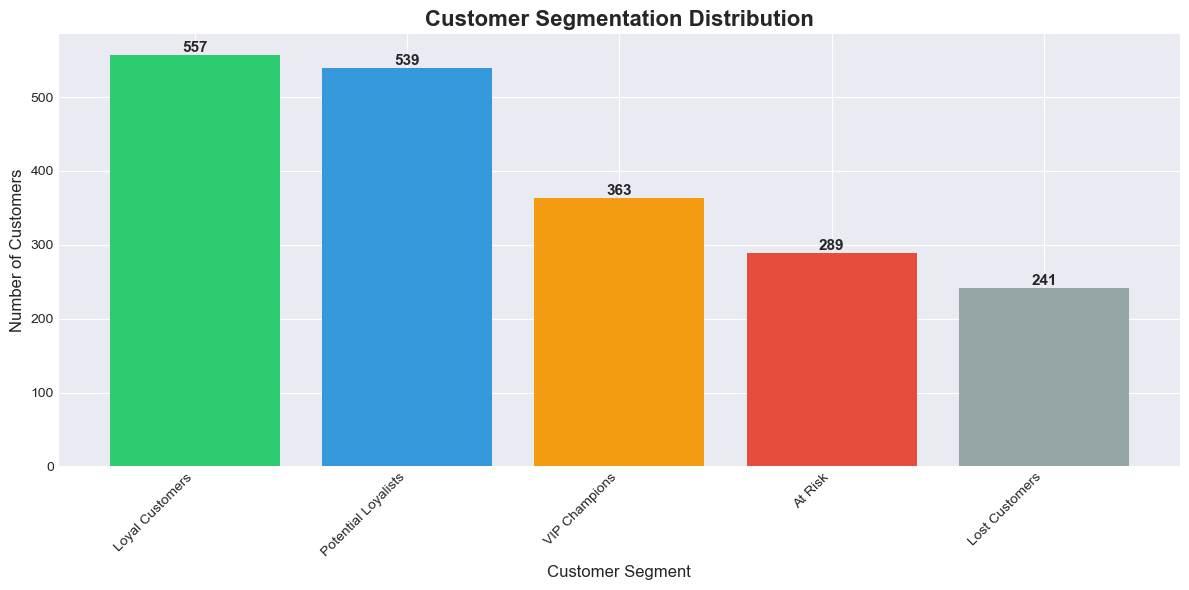

In [95]:
# Visualize customer segments
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(12, 6))
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#95a5a6']
bars = plt.bar(segment_counts.index, segment_counts.values, color=colors)
plt.title('Customer Segmentation Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [96]:
# Segment analysis
segment_analysis = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

segment_analysis['Customer_Count'] = rfm.groupby('Segment').size()
segment_analysis['Revenue_Contribution'] = rfm.groupby('Segment')['Monetary'].sum()

print("\n" + "=" * 60)
print("SEGMENT ANALYSIS")
print("=" * 60)
print(segment_analysis.sort_values('Revenue_Contribution', ascending=False))


SEGMENT ANALYSIS
                     Recency  Frequency  Monetary  Customer_Count  \
Segment                                                             
Loyal Customers        87.80       6.03   4666.92             557   
VIP Champions          42.43       7.79   6623.92             363   
Potential Loyalists   125.57       4.36   3090.50             539   
At Risk               205.65       3.34   2223.54             289   
Lost Customers        366.22       2.07   1255.42             241   

                     Revenue_Contribution  
Segment                                    
Loyal Customers                2599475.79  
VIP Champions                  2404484.14  
Potential Loyalists            1665778.66  
At Risk                         642604.08  
Lost Customers                  302557.11  


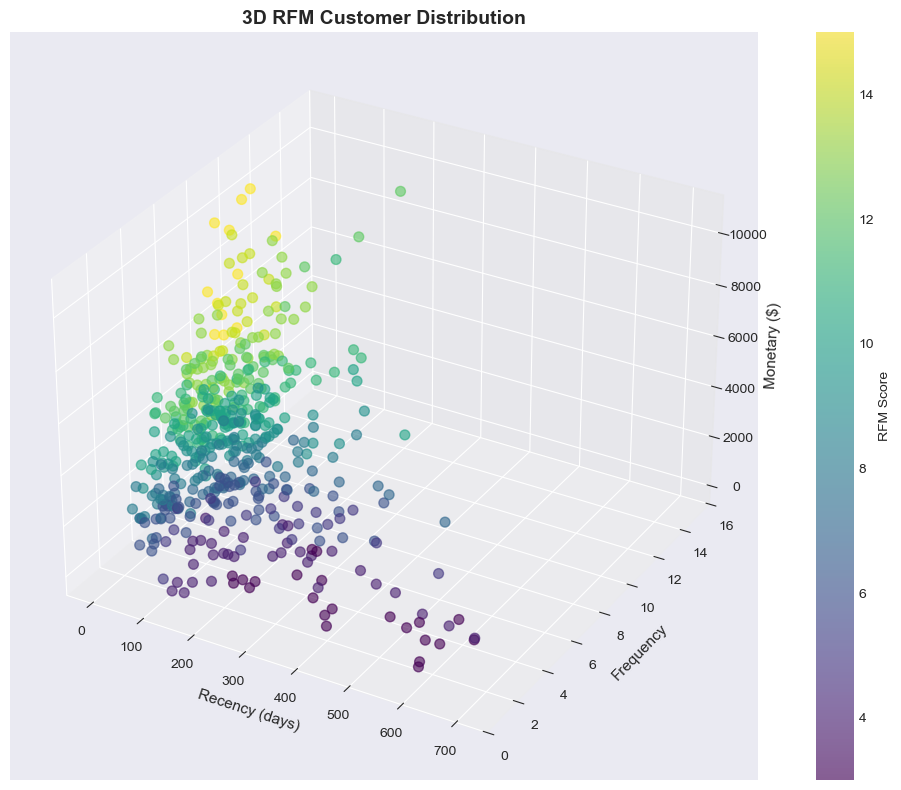

In [97]:
# RFM 3D visualization
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Sample for better visualization
rfm_sample = rfm.sample(min(500, len(rfm)))

scatter = ax.scatter(rfm_sample['Recency'], 
                     rfm_sample['Frequency'], 
                     rfm_sample['Monetary'],
                     c=rfm_sample['RFM_Total'],
                     cmap='viridis',
                     s=50,
                     alpha=0.6)

ax.set_xlabel('Recency (days)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_zlabel('Monetary ($)', fontsize=11)
ax.set_title('3D RFM Customer Distribution', fontsize=14, fontweight='bold')

plt.colorbar(scatter, label='RFM Score')
plt.tight_layout()
plt.show()

## 6. Product Performance Analysis

TOP 10 PRODUCTS BY REVENUE
               total_amount  quantity  orders
product_name                                 
Dress             520021.55      1930     632
Action Figure     512331.19      2006     653
Yoga Mat          506112.03      1969     649
Face Cream        497838.44      2023     667
Jeans             495587.47      2016     677
Headphones        494788.21      1910     652
Blender           488123.83      1890     617
Cookbook          483841.36      1916     642
Dumbbell          472460.94      1872     626
Board Game        465618.96      1850     616


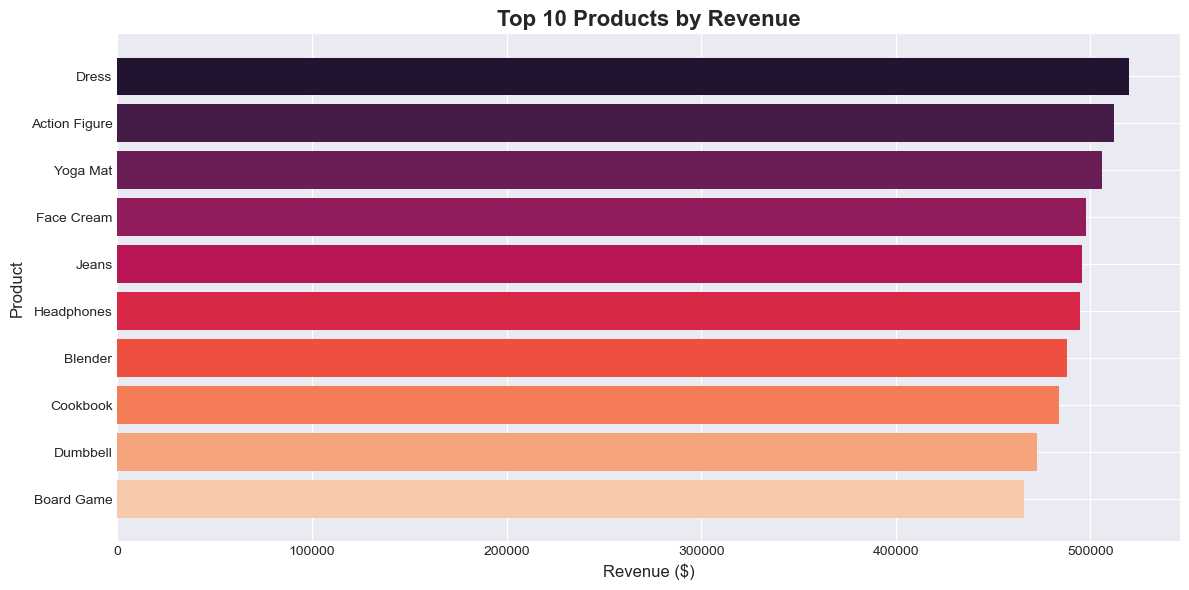

In [98]:
# Top products by revenue
product_performance = df.groupby('product_name').agg({
    'total_amount': 'sum',
    'quantity': 'sum',
    'order_id': 'count'
}).rename(columns={'order_id': 'orders'}).sort_values('total_amount', ascending=False)

print("=" * 60)
print("TOP 10 PRODUCTS BY REVENUE")
print("=" * 60)
print(product_performance.head(10))

# Visualize top 10 products
top10_products = product_performance.head(10)

plt.figure(figsize=(12, 6))
plt.barh(top10_products.index, top10_products['total_amount'], color=sns.color_palette('rocket', 10))
plt.xlabel('Revenue ($)', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.title('Top 10 Products by Revenue', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [99]:
# Category performance matrix
category_matrix = df.groupby('product_category').agg({
    'total_amount': ['sum', 'mean'],
    'quantity': 'sum',
    'order_id': 'count'
})
category_matrix.columns = ['Total_Revenue', 'Avg_Order_Value', 'Units_Sold', 'Orders']
category_matrix = category_matrix.sort_values('Total_Revenue', ascending=False)

print("\n" + "=" * 60)
print("CATEGORY PERFORMANCE MATRIX")
print("=" * 60)
print(category_matrix)


CATEGORY PERFORMANCE MATRIX
                  Total_Revenue  Avg_Order_Value  Units_Sold  Orders
product_category                                                    
Electronics          1917710.81       767.391281        7443    2499
Clothing             1564397.88       763.493353        6082    2049
Home & Kitchen       1126699.39       756.174087        4488    1490
Books                 909331.20       745.964889        3623    1219
Beauty                774159.63       764.224709        3060    1013
Sports                709626.21       757.338538        2855     937
Toys                  612974.66       772.981917        2418     793


## 7. Temporal Analysis

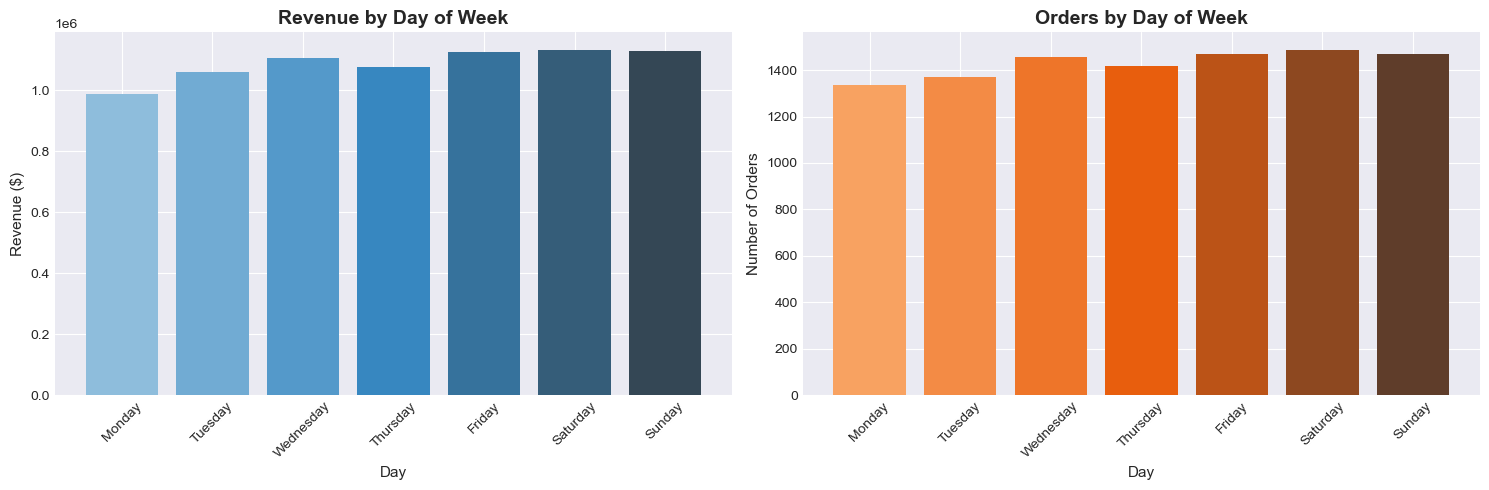


📊 Best day for revenue: Saturday
📊 Best day for orders: Saturday


In [100]:
# Day of week analysis
df['day_of_week'] = df['order_date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

dow_revenue = df.groupby('day_of_week')['total_amount'].sum().reindex(day_order)
dow_orders = df.groupby('day_of_week')['order_id'].count().reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Revenue by day
axes[0].bar(dow_revenue.index, dow_revenue.values, color=sns.color_palette('Blues_d', 7))
axes[0].set_title('Revenue by Day of Week', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Day', fontsize=11)
axes[0].set_ylabel('Revenue ($)', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)

# Orders by day
axes[1].bar(dow_orders.index, dow_orders.values, color=sns.color_palette('Oranges_d', 7))
axes[1].set_title('Orders by Day of Week', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day', fontsize=11)
axes[1].set_ylabel('Number of Orders', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\n📊 Best day for revenue: {dow_revenue.idxmax()}")
print(f"📊 Best day for orders: {dow_orders.idxmax()}")

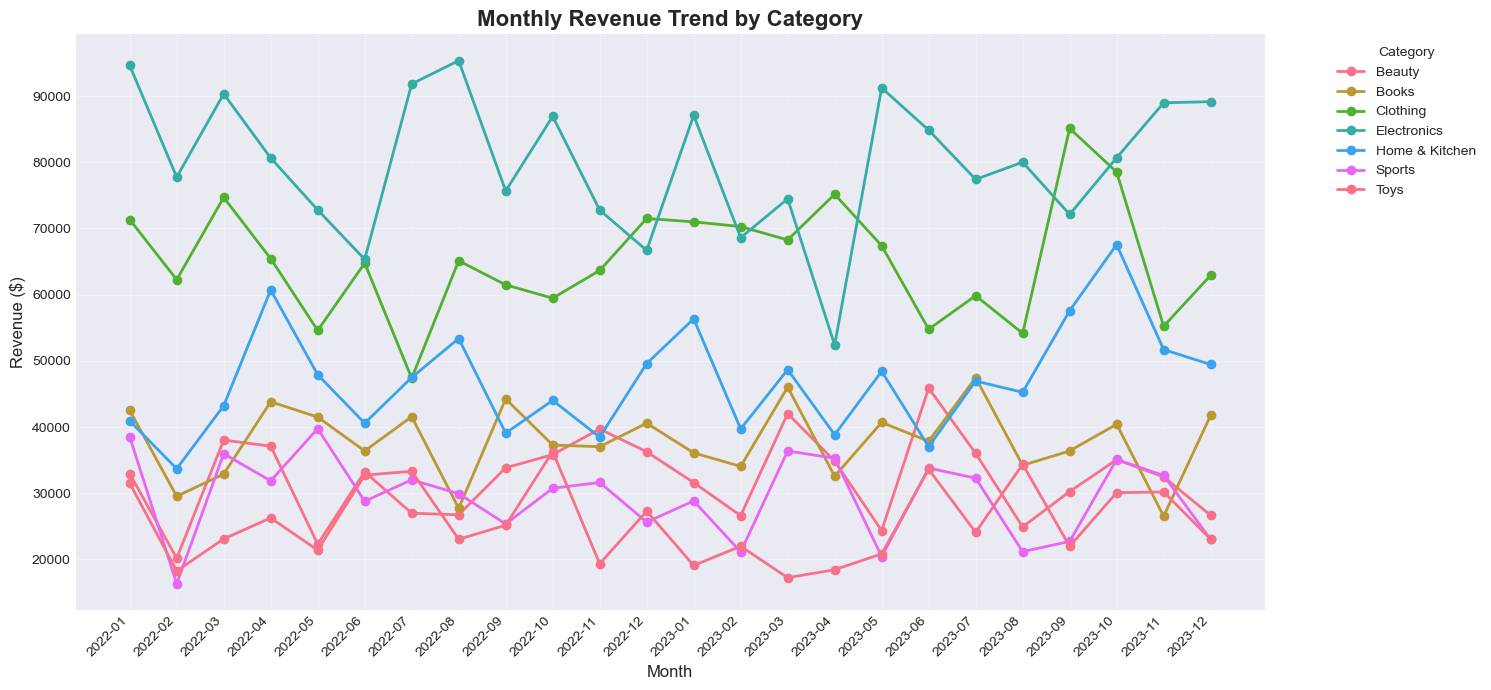

In [101]:
# Monthly trends by category
monthly_category = df.groupby(['year_month', 'product_category'])['total_amount'].sum().unstack(fill_value=0)

plt.figure(figsize=(15, 7))
for column in monthly_category.columns:
    plt.plot(range(len(monthly_category)), monthly_category[column], marker='o', label=column, linewidth=2)

plt.title('Monthly Revenue Trend by Category', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(range(len(monthly_category)), monthly_category.index.astype(str), rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Payment Method Analysis

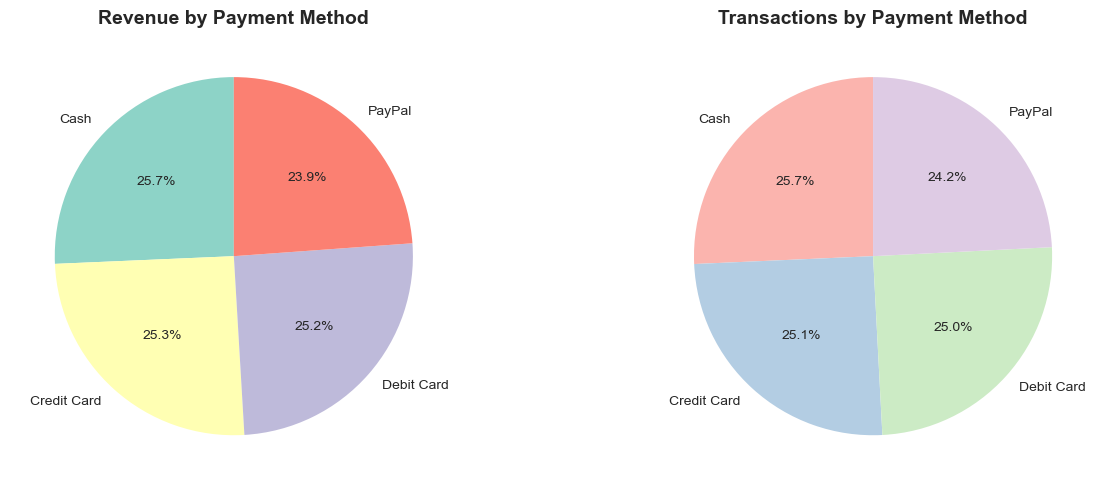


Payment Method Analysis:
                total_amount  transactions
payment_method                            
Cash              1955939.53          2570
Credit Card       1923046.14          2513
Debit Card        1919547.90          2497
PayPal            1816366.21          2420


In [102]:
# Payment method distribution
payment_analysis = df.groupby('payment_method').agg({
    'total_amount': 'sum',
    'order_id': 'count'
}).rename(columns={'order_id': 'transactions'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By revenue
axes[0].pie(payment_analysis['total_amount'], labels=payment_analysis.index, autopct='%1.1f%%',
            startangle=90, colors=sns.color_palette('Set3'))
axes[0].set_title('Revenue by Payment Method', fontsize=14, fontweight='bold')

# By count
axes[1].pie(payment_analysis['transactions'], labels=payment_analysis.index, autopct='%1.1f%%',
            startangle=90, colors=sns.color_palette('Pastel1'))
axes[1].set_title('Transactions by Payment Method', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nPayment Method Analysis:")
print(payment_analysis.sort_values('total_amount', ascending=False))

## 9. Advanced Analytics - Cohort Analysis

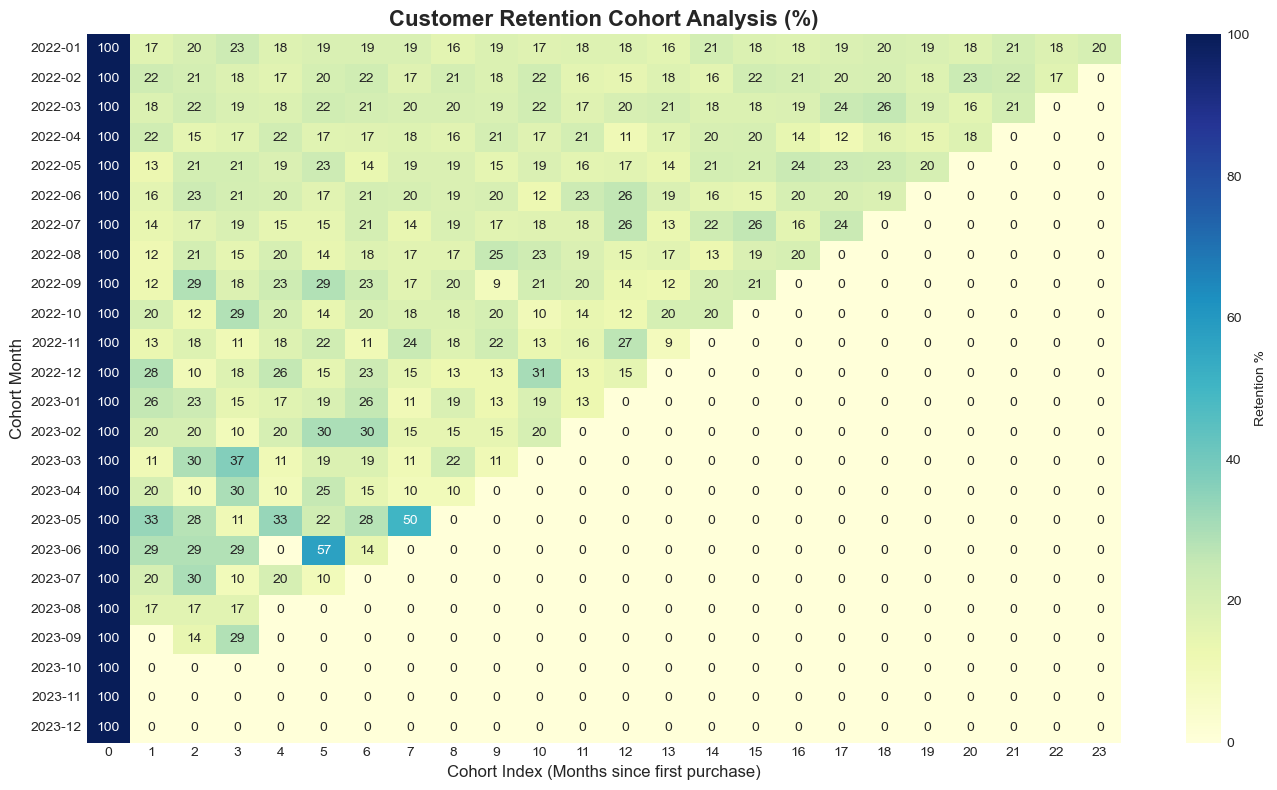


 Average 3-month retention: 17.4%
  Average 6-month retention: 15.1%


In [103]:
# Customer cohort analysis
df['order_month'] = df['order_date'].dt.to_period('M')

# First purchase month for each customer
cohort_data = df.groupby('customer_id')['order_month'].min().reset_index()
cohort_data.columns = ['customer_id', 'cohort_month']

# Merge back
df_cohort = df.merge(cohort_data, on='customer_id')
df_cohort['cohort_index'] = (df_cohort['order_month'] - df_cohort['cohort_month']).apply(lambda x: x.n)

# Cohort size
cohort_size = df_cohort.groupby('cohort_month')['customer_id'].nunique()

# Retention matrix
retention = df_cohort.groupby(['cohort_month', 'cohort_index'])['customer_id'].nunique().unstack(fill_value=0)
retention_pct = retention.divide(cohort_size, axis=0) * 100

# Plot cohort retention
plt.figure(figsize=(14, 8))
sns.heatmap(retention_pct, annot=True, fmt='.0f', cmap='YlGnBu', cbar_kws={'label': 'Retention %'})
plt.title('Customer Retention Cohort Analysis (%)', fontsize=16, fontweight='bold')
plt.xlabel('Cohort Index (Months since first purchase)', fontsize=12)
plt.ylabel('Cohort Month', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\n Average 3-month retention: {retention_pct[3].mean():.1f}%")
print(f"  Average 6-month retention: {retention_pct[6].mean():.1f}%" if 6 in retention_pct.columns else "")

## 10. Key Insights & Business Recommendations

In [104]:
print("=" * 80)
print("KEY INSIGHTS & BUSINESS RECOMMENDATIONS")
print("=" * 80)

print("\n📊 SALES PERFORMANCE")
print("-" * 80)
print(f"✓ Total revenue generated: ${total_revenue:,.2f}")
print(f"✓ Average order value: ${avg_order_value:.2f}")
print(f"✓ Top category: {category_revenue.index[0]} (${category_revenue.values[0]:,.2f})")
print(f"✓ Best performing region: {regional_data['total_amount'].idxmax()}")

print("\n👥 CUSTOMER INSIGHTS")
print("-" * 80)
vip_count = (rfm['Segment'] == 'VIP Champions').sum()
vip_revenue = rfm[rfm['Segment'] == 'VIP Champions']['Monetary'].sum()
print(f"✓ VIP Champions: {vip_count} customers generating ${vip_revenue:,.2f}")
print(f"✓ Average customer lifetime value: ${rfm['Monetary'].mean():.2f}")
at_risk = (rfm['Segment'] == 'At Risk').sum()
print(f"✓ At-risk customers needing re-engagement: {at_risk}")

print("\n💡 RECOMMENDATIONS")
print("-" * 80)
print("1. CUSTOMER RETENTION")
print("   → Launch VIP loyalty program for Champions segment")
print("   → Create win-back campaign for At-Risk customers")
print("   → Implement personalized email marketing based on RFM segments")

print("\n2. PRODUCT STRATEGY")
top_cat = category_revenue.index[0]
print(f"   → Expand inventory in {top_cat} category (highest revenue)")
print("   → Bundle slow-moving products with bestsellers")
print("   → Analyze profit margins by category for optimization")

print("\n3. REGIONAL EXPANSION")
best_region = regional_data['total_amount'].idxmax()
print(f"   → Replicate {best_region} region success strategies in other regions")
print("   → Investigate underperforming regions for market opportunities")
print("   → Consider localized marketing campaigns")

print("\n4. OPERATIONAL IMPROVEMENTS")
best_day = dow_revenue.idxmax()
print(f"   → Optimize inventory for {best_day} (peak sales day)")
print("   → Implement flash sales on low-traffic days")
print("   → Analyze seasonal patterns for demand forecasting")

print("\n" + "=" * 80)

KEY INSIGHTS & BUSINESS RECOMMENDATIONS

📊 SALES PERFORMANCE
--------------------------------------------------------------------------------
✓ Total revenue generated: $7,614,899.78
✓ Average order value: $761.49
✓ Top category: Electronics ($1,917,710.81)
✓ Best performing region: South

👥 CUSTOMER INSIGHTS
--------------------------------------------------------------------------------
✓ VIP Champions: 363 customers generating $2,404,484.14
✓ Average customer lifetime value: $3828.51
✓ At-risk customers needing re-engagement: 289

💡 RECOMMENDATIONS
--------------------------------------------------------------------------------
1. CUSTOMER RETENTION
   → Launch VIP loyalty program for Champions segment
   → Create win-back campaign for At-Risk customers
   → Implement personalized email marketing based on RFM segments

2. PRODUCT STRATEGY
   → Expand inventory in Electronics category (highest revenue)
   → Bundle slow-moving products with bestsellers
   → Analyze profit margins by c

## 11. Export Results

In [105]:
# Save processed data
df.to_csv('sales_data_cleaned.csv', index=False)
rfm.to_csv('customer_rfm_segments.csv')
product_performance.to_csv('product_performance.csv')

print("   Analysis complete! Files exported:")
print("   - sales_data_cleaned.csv")
print("   - customer_rfm_segments.csv")
print("   - product_performance.csv")

   Analysis complete! Files exported:
   - sales_data_cleaned.csv
   - customer_rfm_segments.csv
   - product_performance.csv


---
## Summary

This comprehensive e-commerce analysis project demonstrates:
- ✅ Data manipulation and cleaning with pandas
- ✅ Advanced customer segmentation (RFM analysis)
- ✅ Sales trend analysis and forecasting
- ✅ Multi-dimensional visualization techniques
- ✅ Business intelligence and actionable insights
- ✅ Cohort analysis for retention metrics

**Skills Demonstrated:** Python, Pandas, NumPy, Matplotlib, Seaborn, Data Analysis, Business Intelligence, Customer Analytics

**Perfect for:** Data Analyst portfolio, job applications, and showcasing analytical capabilities